<a href="https://colab.research.google.com/github/reyesc1710/Telecom-Analysis/blob/main/S7Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:

# mostrar las primeras 5 filas de plans
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos por columna (users):")
print(users.isna().sum())
print("\nProporción de valores nulos por columna (users):")
print(users.isna().mean())


Cantidad de valores nulos por columna (users):
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos por columna (users):
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos por columna (usage):")
print(usage.isna().sum())
print("\nProporción de valores nulos por columna (usage):")
print(usage.isna().mean())

Cantidad de valores nulos por columna (usage):
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos por columna (usage):
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Comentario personal**
- usage.date tiene 0.13% de nulos (50 registros) la proporción mínima (<5%); lo que se puede hacer es ver las filas y eliminar esas filas puntuales sin impacto en el análisis.
- usage.duration tiene 55.19% de nulo, corresponde a filas donde type no es 'call' en este caso el campo no aplica; se deja como nulo estructural y se filtra por type al analizar.
- usage.length tiene 44.74% de nulos, es el mismo caso que el anterior: aplica solo a type 'message'; se deja como nulo estructural, no se imputa.
- users.city tiene 11.73% de nulos es un rango medio (5–30%); mi recomendaci[on es investigar el patrón y, si no se recupera el dato, se imputa como "unknown" para no perder las filas.
- users.churn_date tiene 88.35% de nulos es una proporción alta (>80%) de los datos, pero no indica un error, lo que significa que el usuario sigue activo; se deja como nulo y, si se requiere, se crea una columna auxiliar colocando activo en vez de imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [ ]:

# explorar columnas categóricas de users
for col in ['city', 'plan']:  # ajusta según los nombres reales de tus columnas
    print(f"\n--- {col} ---")
    print(users[col].unique())
    print(f"Valores únicos: {users[col].nunique()}")




--- city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Valores únicos: 7

--- plan ---
['Basico' 'Premium']
Valores únicos: 2


- La columna `city` ...
- La columna `plan` ...

In [ ]:
# explorar columna categórica de usage
for col in usage.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(usage[col].unique())



--- type ---
['call' 'text']

--- date ---
['2024-01-01 00:00:00.000000000' '2024-01-01 00:06:30.969774244'
 '2024-01-01 00:13:01.939548488' ... '2024-06-29 23:46:58.060451510'
 '2024-06-29 23:53:29.030225754' '2024-06-30 00:00:00.000000000']


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Comentario personal**
- users.age: el mínimo es -999, un valor que no existe como edad. Esto es un sentinel típico usado para marcar "dato no disponible". Mi acción sería reemplazar -999 por NaN o decidir si se imputa con la mediana o se deja como nulo, dependiendo de cuántos casos sean.
- users.city: aparece el valor '?', que es un sentinel de texto dewsconocido. También hay inconsistencia de formato con nombres completos mezclados con abreviaciones. Lo que haría sería reemplazar '?' por NaN y estandarizar las abreviaciones a nombre completo para tener uniformidad.
- users.plan: solo tiene 2 valores ('Basico', 'Premium') son consistentes y sin sentinels, por lo que no hay que hacer nada.
- usage.type: sólo hay 'call' y 'text', sin sentinel y no requiere acción.
- usage.duration: es un rango de 0 a 120, sin negativos y valores extremos sin sentido, no se detecta sentinel.
- usage.length: el rango es de 0 a 1490, con media de 52, pero el máximo es 1490 podría parecer un outlier, pero no es imposible para longitud de un mensaje de texto largo. Lo que haría es revisar la distribución en percentiles o un histograma antes de tratarlo como error, no puedo determinar si es un sentinel sin saber más detalles.
- usage.date: se cuentan valores dentro de un rango razonable, no hay sentinels, solo se debo convertir a date time para usarlo posteriormente.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Comentario Personal**

En la columna reg_date aparecen los años 2022, 2023,2024 y 2026. Sólo hay 40 registros en 2026 representando 1%, lo que nos indica un posible error de captura o de procesamiento de fechas, aquí lo que haría sería validar si se trata un error de captura, si no marcalos como faltantes o excluirlos. En la columna date de usage únicamente aparece el año 2024, por lo que no se observan incosistencias y no se requiere acciones correctivas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
# Crear indicador de nulos
usage['duration_null'] = usage['duration'].isna()
# Proporción de nulos por tipo
usage.groupby('type')['duration_null'].mean() * 100

type
call     0.000000
text    99.927576
Name: duration_null, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length

# Crear indicador de nulos
usage['length_null'] = usage['length'].isna()
# Proporción de nulos por tipo
usage.groupby('type')['length_null'].mean() * 100


type
call    99.932991
text     0.000000
Name: length_null, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Los valores faltantes en duration y lenght dependen directamente de la variable type, por lo que veo no hay errores de captura. En realidad, representan características que no aplican para ciertos tipos de registros:
- duration aplica únicamente a llamadas (call)
- length aplica únicamente a mensajes (text)

Por lo que desde mi perspectiva siguen un patrón MAR asociado al tipo de evento registrado. Entonces los conservaré como nulos y sin imputar.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage['es_mensaje'] = (usage['type'] == 'text').astype(int)
usage['es_llamada'] = (usage['type'] == 'call').astype(int)

# Agrupar información por usuario
usage_resumen = usage.groupby('user_id').agg({
    'es_mensaje': 'sum',
    'es_llamada': 'sum',
    'duration': 'sum'})

# observar resultado
usage_resumen.head()

,es_mensaje,es_llamada,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74
10003,11,3,8.99
10004,4,3,8.01


In [ ]:
# Renombrar columnas
usage_resumen = usage_resumen.rename(columns={
    'es_mensaje': 'cant_mensajes',
    'es_llamada': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'})
# observar resultado
usage_resumen.head()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74
10003,11,3,8.99
10004,4,3,8.01


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
users_usage = users.merge(
    usage_resumen,
    on='user_id',
    how='left')
users_usage.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

# Resumen estadístico de las columnas numéricas
users_usage.describe()
users_usage.median(numeric_only=True)

user_id                 11999.50
age                        48.00
cant_mensajes               5.00
cant_llamadas               4.00
cant_minutos_llamada       19.78
dtype: float64

In [ ]:

# Distribución porcentual del tipo de plan
(users_usage['plan']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))



Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

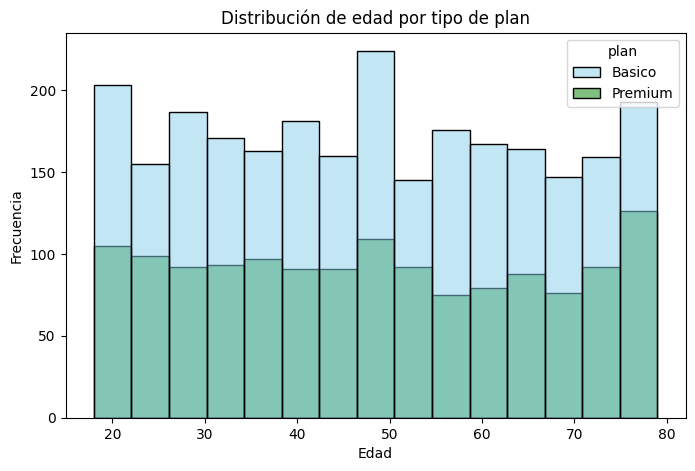

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(
    data=users_usage,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15,
    multiple='layer')

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- Distribución es un poco uniforme entre los 18 a 80 años, no hay grandes variaciones.
- Los planes Básico y Premium están en todos los rangos de edad. Por lo que no observó un factor determinante para la elección de plan.

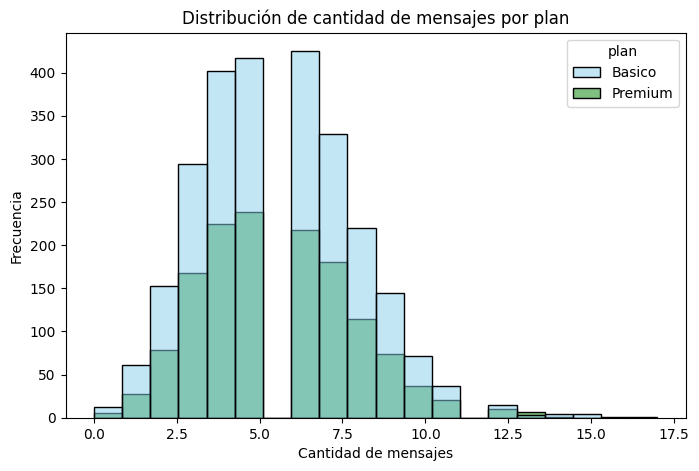

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=users_usage,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La mayor concentración de usuarios de ambos planes se encuentra entre el 3 y 8 mensajes.
- El tipo de distribución es sesgada a la derecha.
- Las distribuciones entre planes son similares y presentan un alto grado de posición.
- Apartir de más de 12 mensajes si existen usuarios pero es la minoría.

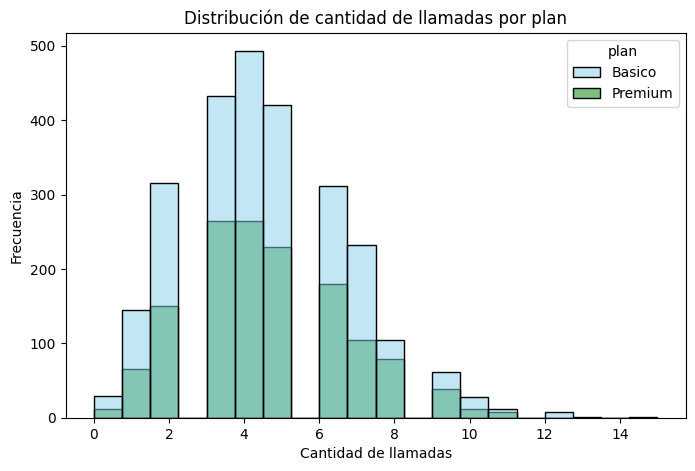

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=users_usage,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución es sesgada a la derecha, la mayoría de usuarios hace entre 3 a 7 llamadas.
- Existe un menor número de usuarios que hacen más de 10 llamadas y representan una proporción más pequeña.

Text(0, 0.5, 'Frecuencia')

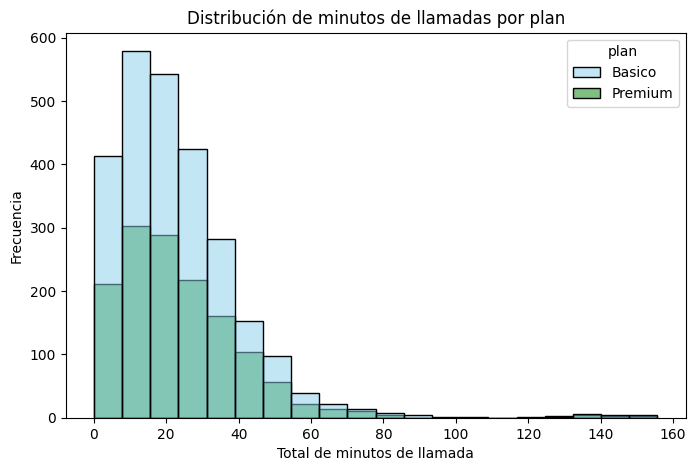

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=users_usage,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')

💡Insights:
- Distribución es sesgada a la derecha, la mayoría de usuarios acumula entre 5 y 40 minutos de llamadas.
- La frecuencia disminuye gradualmente a medida que aumentan los minutos consumidos.
- Hay muy pocos usuarios con consumos elevados mayores a 100 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

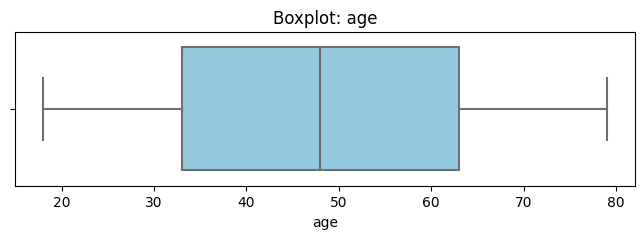

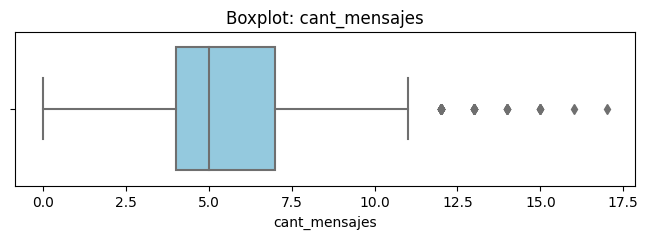

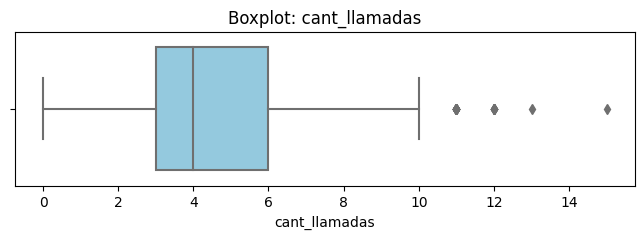

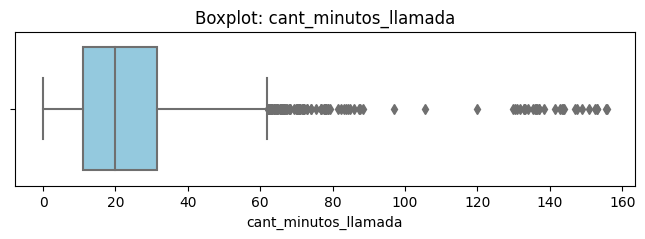

In [ ]:


# Visualizando usando BoxPlot
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=users_usage[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights:
- Age: No presenta outliers, todos se encuentran dentro del límite en el boxplot entre 18 a 80 años.
- cant_mensajes: Sí presenta outliers, se observan varios usuarios entre 12 y 17 mensajes, por encima del límite.
- cant_llamadas: Sí presenta outliers, se observan varios usuarios entre 11 y 15 llamadas, son altos comparados con los típicos.
- cant_minutos_llamada:  Sí presenta outliers, se observan varios usuarios por encima de los 60 minutos hasta 160, es una variable con valores muy extremos.

In [ ]:
# Calcular límites con el método IQR
for col in columnas_numericas:
    Q1 = users_usage[col].quantile(0.25)
    Q3 = users_usage[col].quantile(0.75)

    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = users_usage[
        (users_usage[col] < limite_inferior) |
        (users_usage[col] > limite_superior)]

    print(f'\n{col}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Cantidad de outliers: {len(outliers)}')




age
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
users_usage[[
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Se identificaron 46 outliers por encima del límite superior de 11.5 mensajes. El valor máximo observado es 17 mensajes, que no esta muy alejado, por lo que podemos mantenerlos.
- cant_llamadas:Tenemos 30 outliers con un límite superior de 10.5 llamadas, teniendo un valor máximo de 15 llamadas, podemos mantener no es un valor muy extremos y ayudan al análisis de tenendencia de usuarios.
- cant_minutos_llamada: Se identificaron 109 outliers, el límite es de 61.86 minutos. El valor máximo es de 155.69, aunque existe una diferencia considerable respecto al resto de los usuarios, estos valores siguen siendo posibles, no hay errores de captura, por lo que los mantendría para no sesgar el resultado y ver toda la tendencia.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
users_usage['grupo_uso'] = 'Alto uso'
users_usage.loc[
    (users_usage['cant_llamadas'] < 5) &
    (users_usage['cant_mensajes'] < 5),
    'grupo_uso'
    ] = 'Bajo uso'

users_usage.loc[
    (users_usage['cant_llamadas'] < 10) &
    (users_usage['cant_mensajes'] < 10) &
    (users_usage['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
    ] = 'Uso medio'

In [ ]:
# verificar cambios
users_usage[['cant_mensajes', 'cant_llamadas', 'grupo_uso']].head()

,cant_mensajes,cant_llamadas,grupo_uso
0,7.0,3.0,Uso medio
1,5.0,10.0,Alto uso
2,5.0,2.0,Uso medio
3,11.0,3.0,Alto uso
4,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
users_usage['grupo_edad'] = 'Adulto Mayor'
users_usage.loc[
    users_usage['age'] < 30,
    'grupo_edad'
    ] = 'Joven'
users_usage.loc[
    (users_usage['age'] >= 30) &
    (users_usage['age'] < 60),
    'grupo_edad'
    ] = 'Adulto'

In [ ]:

# verificar cambios
users_usage[['age', 'grupo_edad']].head(10)

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor
5,61.0,Adulto Mayor
6,39.0,Adulto
7,70.0,Adulto Mayor
8,76.0,Adulto Mayor
9,47.0,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

<AxesSubplot:xlabel='grupo_uso', ylabel='count'>

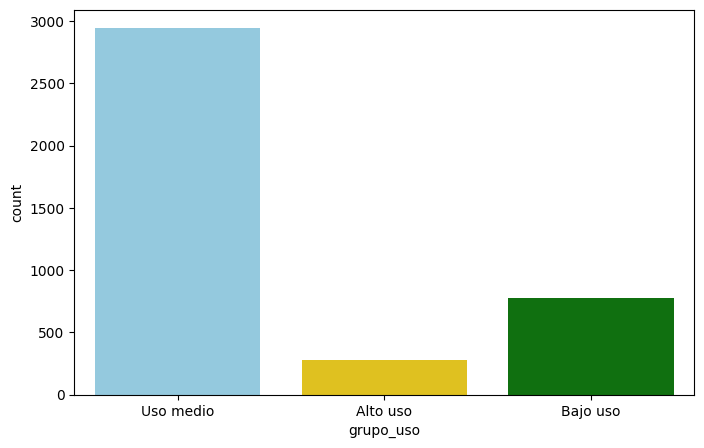

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))
sns.countplot(
    data=users_usage,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green'])

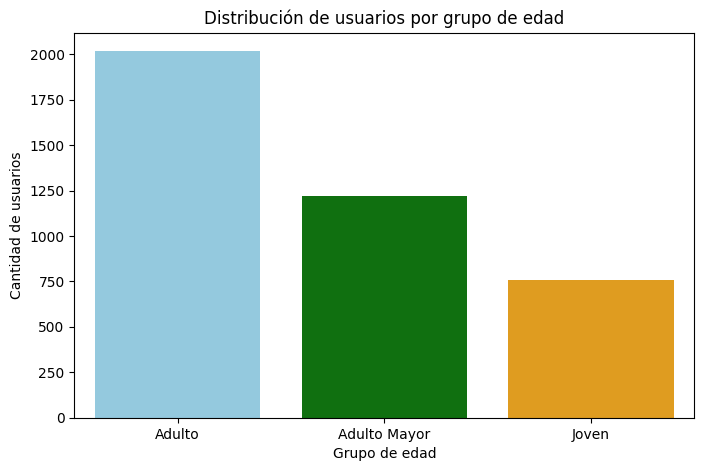

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))
sns.countplot(
    data=users_usage,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la etapa de limpieza se identificaron los siguientes problemas:
- En la variable age existían valores sentinel -999, los cuales representaban edades inválidas. Los cuales fueron reemplazados por la mediana para evitar distorsionar el análisis.
- En la variable city se encontraron valores "?", utilizados como marcador de dato faltante. Estos fueron reemplazados por valores nulos (NA).
- En la variable reg_date se detectaron 40 registros con fecha de 2026, aunque el negocio indicó que los datos llegan únicamente hasta 2024. Estos registros fueron considerados inconsistencias y se marcaron como nulos (NaT).
- Se verificó que los nulos en duration y length no correspondían a errores, sino a valores que no aplicaban según el tipo de evento (call o text), por lo que se conservaron.

🔍 **Segmentos por Edad**
Se identificaron tres grupos de edad:
- Adultos (30-59 años): representan el segmento más grande de la base de clientes, con aproximadamente la mitad de los usuarios.
- Adultos Mayores (60 años o más): constituyen el segundo grupo más numeroso.
- Jóvenes (menores de 30 años): representan la menor proporción de usuarios.

Nos indica que ConnectaTel sus clientes están compuestos principalmente por usuarios adultos.

📊 **Segmentos por Nivel de Uso**
- Bajo uso: aproximadamente 780 usuarios. Corresponde a clientes con poca actividad en llamadas y mensajes.
- Medio uso: aproximadamente 2,950 usuarios. Es el segmento dominante y representa la mayoría de la base.
- Alto uso: aproximadamente 280 usuarios. Es el grupo más pequeño, pero potencialmente el más rentable.

➡️ Esto sugiere que la mayoría de los clientes utiliza los servicios de forma moderada, mientras que existe un grupo reducido con un consumo significativamente mayor.


💡 **Recomendaciones**
- La empresa ConnectaTel podría crear planes diferenciados para usuarios de alto consumo, cómo el incluir más minutos y beneficios exclusivos para retener a los clientes más activos y que sigan siendo leales.

- Diseñar estrategias de migración para usuarios de uso medio, que ofrezcan promociones para intecentivar el crecimiento a planes superiores y vean más beneficiosfrecer promociones que incentiven su paso a planes superiores.

- Aquellos usuarios con planes económicos y para usuarios de bajo consumo, crear dinámicas para aumentar beneficios y así vean que si importan dentro de la compañía, esto evitaría la pérdida de clientes que lo utilizan de manera ocasional.

- Se podrían crear campañas por edad así las personas les atrae las promociones o beneficios.

- ConnectaTel deben considerar que los adultos representan el principal mercado objetivo y deberían recibir la mayor atención comercial y mayores promociones, sin dejar a un lado a los jóvenes porque podrían beneficiarse de planes digitales y promociones orientadas a mensajería. En el segmento de adultos mayores podrían valorar planes sencillos con beneficios enfocados en llamadas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`